In [1]:
from pytorch_tabnet.tab_model import TabNetClassifier

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import numpy as np
import random

import scipy
from matplotlib import pyplot as plt
%matplotlib inline

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


In [2]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Load diabetes dataset

In [3]:
df=pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
print('data shape:',df.shape)
print('columns',df.columns.tolist())
print(df.isnull().sum())
df.head()

data shape: (253680, 22)
columns ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
#targte:Diabetes(0:healthy; 1:pre-diabetic; 2:diabetes)
#features(21):'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack','PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
target_col='Diabetes_012'
y=df[target_col].values.astype(int)
X=df.drop(columns=[target_col])

feature_names=X.columns.tolist()
print(feature_names)
print( 'number of features:',len(feature_names))


['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
number of features: 21


## Define categorical features for categorical embeddings

In [5]:
#categorical features
cat_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "GenHlth",
    "DiffWalk", "Sex", "Age", "Education", "Income"
]
#continous features
cont_cols = ["BMI", "MentHlth", "PhysHlth"]
# 对 categorical 列做 0~N-1 编码
for c in cat_cols:
    X[c], _ = pd.factorize(X[c])   # 每一列单独编码成 0..num_unique-1

feature_names = X.columns.tolist()
cat_idxs = [feature_names.index(c) for c in cat_cols]
cat_dims = [int(X[c].nunique()) for c in cat_cols]

print("Categorical columns:", cat_cols)
print("Continuous columns:", cont_cols)
print("cat_idxs:", cat_idxs)
print("cat_dims:", cat_dims)



Categorical columns: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Continuous columns: ['BMI', 'MentHlth', 'PhysHlth']
cat_idxs: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20]
cat_dims: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 2, 13, 6, 8]


## Split dataset(train/val/test) and normalization


In [6]:
X_np = X.values.astype(np.float32)
y_np = y

#train(0.8)/test(0.2)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_np, y_np,
    test_size=0.2,
    random_state=SEED,
    stratify=y_np
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,  
    random_state=SEED,
    stratify=y_train_val
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape, "Test shape:", X_test.shape)


Train shape: (162355, 21) Valid shape: (40589, 21) Test shape: (50736, 21)


In [7]:
#standard scale for continuous feartures
from copy import deepcopy

X_train_scaled = deepcopy(X_train)
X_valid_scaled = deepcopy(X_valid)
X_test_scaled  = deepcopy(X_test)

cont_idxs = [feature_names.index(c) for c in cont_cols]

for idx in cont_idxs:
    mean = X_train[:, idx].mean()
    std = X_train[:, idx].std() + 1e-6  
    X_train_scaled[:, idx] = (X_train[:, idx] - mean) / std
    X_valid_scaled[:, idx] = (X_valid[:, idx] - mean) / std
    X_test_scaled[:, idx]  = (X_test[:, idx]  - mean) / std

X_train_tab = X_train_scaled
X_valid_tab = X_valid_scaled
X_test_tab  = X_test_scaled

In [ ]:
#class weight
class_counts = np.bincount(y_train)
# base:1/sqrt(count) 
base_weights = 1.0 / np.sqrt(class_counts + 1e-6)
base_weights = base_weights / base_weights.mean()

# bias
w0, w1, w2 = base_weights
w1 = w1 * 2.0   
class_weights = np.array([w0, w1, w2])
class_weights = class_weights / class_weights.mean()

print("Class counts (train):", class_counts)
print("Class weights:", class_weights)

train_weights = np.array([class_weights[c] for c in y_train])

Class counts (train): [136769   2964  22622]
Class weights: [0.17600868 2.39121606 0.43277526]


## Network parameters

In [ ]:
n_classes=len(np.unique(y_np))
tabnet_params={
    "n_d":32,
    "n_a":32,
    "n_steps":5,
    "gamma":1.5,
    "n_independent":2,
    "n_shared":2,
    "cat_idxs":cat_idxs,
    "cat_dims":cat_dims,
    "cat_emb_dim":3,
    "optimizer_fn":torch.optim.Adam,
    "optimizer_params":dict(lr=5e-3),
    "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                    "gamma":0.9},
    "scheduler_fn":torch.optim.lr_scheduler.StepLR,
    "mask_type":'entmax', # "sparsemax",
    "verbose":10
}
clf=TabNetClassifier(**tabnet_params)

/home/imnotpxy/miniforge3/envs/cnn/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


## Training

In [10]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

/home/imnotpxy/miniforge3/envs/cnn/lib/python3.12/site-packages/_distutils_hack/__init__.py:53: UserWarning: Reliance on distutils from stdlib is deprecated. Users must rely on setuptools to provide the distutils module. Avoid importing distutils or import setuptools first, and avoid setting SETUPTOOLS_USE_DISTUTILS=stdlib. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


epoch 0  | loss: 0.88631 | train_accuracy: 0.80812 | train_balanced_accuracy: 0.45986 | valid_accuracy: 0.80862 | valid_balanced_accuracy: 0.46036 |  0:00:14s
epoch 10 | loss: 0.80309 | train_accuracy: 0.811   | train_balanced_accuracy: 0.47196 | valid_accuracy: 0.80946 | valid_balanced_accuracy: 0.46703 |  0:02:38s
epoch 20 | loss: 0.7789  | train_accuracy: 0.79735 | train_balanced_accuracy: 0.50191 | valid_accuracy: 0.79396 | valid_balanced_accuracy: 0.47437 |  0:04:57s
epoch 30 | loss: 0.64674 | train_accuracy: 0.78827 | train_balanced_accuracy: 0.66448 | valid_accuracy: 0.76839 | valid_balanced_accuracy: 0.46357 |  0:07:16s

Early stopping occurred at epoch 38 with best_epoch = 23 and best_valid_balanced_accuracy = 0.4839


/home/imnotpxy/miniforge3/envs/cnn/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


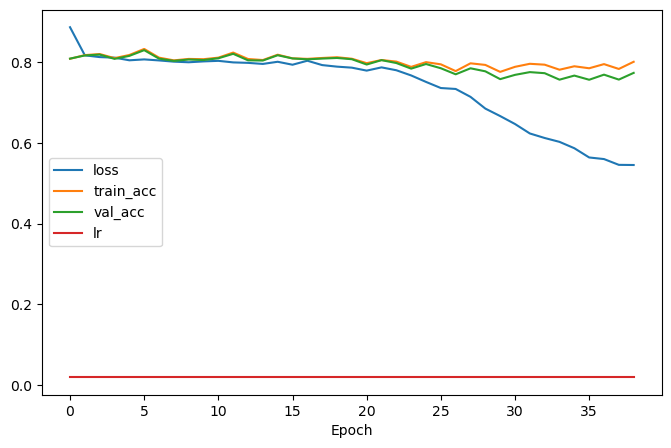

In [11]:
max_epochs = 50
batch_size = 1024
# Fitting the model 
clf.fit(
    X_train_tab, y_train,
eval_set=[(X_train_tab, y_train), (X_valid_tab, y_valid)],
eval_name=["train", "valid"],
eval_metric=["accuracy","balanced_accuracy"],
max_epochs=max_epochs,
batch_size=batch_size,
patience=15,            # early stopping
weights=train_weights,  
drop_last=False,
num_workers=0,   
)

plt.figure(figsize=(8, 5))
plt.plot(clf.history['loss'], label='loss')
plt.plot(clf.history['train_accuracy'], label='train_acc')
plt.plot(clf.history['valid_accuracy'], label='val_acc')
plt.plot(clf.history['lr'], label='lr')
plt.legend()
plt.xlabel("Epoch")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

y_pred_val = clf.predict(X_valid_tab)

print("Overall accuracy:", (y_pred_val == y_valid).mean())
print("Balanced accuracy:", balanced_accuracy_score(y_valid, y_pred_val))

print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(y_valid, y_pred_val, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_valid, y_pred_val))


Overall accuracy: 0.7838084210007638
Balanced accuracy: 0.48389536174861525

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

           0     0.9145    0.8406    0.8760     34193
           1     0.0371    0.0783    0.0503       741
           2     0.3967    0.5328    0.4548      5655

    accuracy                         0.7838     40589
   macro avg     0.4494    0.4839    0.4604     40589
weighted avg     0.8263    0.7838    0.8022     40589

Confusion matrix:
[[28743  1127  4323]
 [  423    58   260]
 [ 2264   378  3013]]
